In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

!pip install bertopic
from bertopic import BERTopic

!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans

!pip install hdbscan
import hdbscan

from sklearn.preprocessing import normalize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.5 MB/s eta 0:00:00


In [2]:
file_path = "/content/corpus_20ng.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]

df = df.drop(columns=["split"])

# Preview
df.head()

,text,label
0,\n\nI am sure some bashers of Pens fans are pr...,rec.sport.hockey
1,My brother is in the market for a high-perform...,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,comp.sys.mac.hardware


In [3]:
texts = df["text"].astype(str).tolist()
texts

["\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n",
 'My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any other high-per

In [4]:
from umap import UMAP

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42)


topic_model = BERTopic(
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)

print(topics[:10])

2026-05-11 12:30:01,034 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/514 [00:00<?, ?it/s]

2026-05-11 12:57:09,527 - BERTopic - Embedding - Completed ✓
2026-05-11 12:57:09,529 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 12:57:53,646 - BERTopic - Dimensionality - Completed ✓
2026-05-11 12:57:53,649 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 12:58:01,079 - BERTopic - Cluster - Completed ✓
2026-05-11 12:58:01,089 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 12:58:04,867 - BERTopic - Representation - Completed ✓


[0, -1, -1, 2, 65, 114, -1, 0, 0, -1]


In [5]:
len(set(topics))

209

In [6]:
# Top words per topic — these are your "themes"
topic_model.get_topic_info().head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5628,-1_to_the_of_and,"[to, the, of, and, you, is, in, for, it, that]",[Why should anyone (check: let's restrict this...
1,0,1626,0_game_team_he_games,"[game, team, he, games, players, season, hocke...","[\nWales Conference, Adams Division, Semifinal..."
2,1,501,1_key_clipper_chip_encryption,"[key, clipper, chip, encryption, keys, escrow,...","[[An article from comp.org.eff.news, EFFector ..."
3,2,407,2_drive_scsi_drives_ide,"[drive, scsi, drives, ide, disk, controller, h...",[\n\n\n\n\n\nI have been using both IDE (or MF...
4,3,354,3_israel_israeli_arab_arabs,"[israel, israeli, arab, arabs, jews, palestini...",[From: Center for Policy Research <cpr>\nSubje...
5,4,344,4_car_cars_engine_ford,"[car, cars, engine, ford, price, mustang, toyo...",[\nOn the subject of the upcoming new Mustang:...
6,5,252,5_fbi_koresh_fire_compound,"[fbi, koresh, fire, compound, gas, they, batf,...",[\n: Oh? Then why did the smoke and flames sta...
7,6,238,6_bike_ride_riding_my,"[bike, ride, riding, my, lane, you, passenger,...",[\nGlad to hear that the bozo managed to stop....
8,7,235,7_god_atheists_atheism_atheist,"[god, atheists, atheism, atheist, exist, belie...","[\nNo smiley on the part about atheism, I see...."
9,8,138,8_xfree86_motif_server_windows,"[xfree86, motif, server, windows, ftp, mbytes,...",[\n Here's a listing that I came accross a w...


In [7]:
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(tid)[:8]]
    print(f"Topic {tid}: {', '.join(words)}")

Topic 0: game, team, he, games, players, season, hockey, play
Topic 1: key, clipper, chip, encryption, keys, escrow, government, nsa
Topic 2: drive, scsi, drives, ide, disk, controller, hard, scsi2
Topic 3: israel, israeli, arab, arabs, jews, palestinian, jewish, palestinians
Topic 4: car, cars, engine, ford, price, mustang, toyota, dealer
Topic 5: fbi, koresh, fire, compound, gas, they, batf, children
Topic 6: bike, ride, riding, my, lane, you, passenger, car
Topic 7: god, atheists, atheism, atheist, exist, belief, evidence, is
Topic 8: xfree86, motif, server, windows, ftp, mbytes, support, dos
Topic 9: printer, print, deskjet, hp, ink, printers, laser, printing
Topic 10: bike, bikes, miles, motorcycle, honda, engine, ride, rear
Topic 11: window, widget, application, event, expose, events, null, handler
Topic 12: jpeg, image, gif, format, file, files, images, convert
Topic 13: modem, port, serial, irq, ports, com, card, com3
Topic 14: amp, audio, speakers, condition, asking, stereo, o

In [8]:
sum(np.array(topics) == -1)

np.int64(5628)

In [9]:
df["topic"] = topics
df

,text,label,topic
0,\n\nI am sure some bashers of Pens fans are pr...,rec.sport.hockey,0
1,My brother is in the market for a high-perform...,comp.sys.ibm.pc.hardware,-1
2,\n\n\n\n\tFinally you said what you dream abou...,talk.politics.mideast,-1
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,comp.sys.ibm.pc.hardware,2
4,1) I have an old Jasmine drive which I cann...,comp.sys.mac.hardware,65
...,...,...,...
16424,Hi to all.\n\nSince all of you could also be a...,misc.forsale,176
16425,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,sci.med,-1
16426,I just installed a DX2-66 CPU in a clone mothe...,comp.sys.ibm.pc.hardware,86
16427,\nWouldn't this require a hyper-sphere. In 3-...,comp.graphics,18


In [10]:
topic_to_label = {}

for topic_id in set(topics):
    if topic_id == -1:
        continue

    majority_label = (
        df[df["topic"] == topic_id]["label"]
        .mode()[0]
    )

    topic_to_label[topic_id] = majority_label

print(topic_to_label)

{0: 'rec.sport.hockey', 1: 'sci.crypt', 2: 'comp.sys.ibm.pc.hardware', 3: 'talk.politics.mideast', 4: 'rec.autos', 5: 'talk.politics.guns', 6: 'rec.motorcycles', 7: 'alt.atheism', 8: 'comp.windows.x', 9: 'comp.os.ms-windows.misc', 10: 'rec.motorcycles', 11: 'comp.windows.x', 12: 'comp.graphics', 13: 'comp.sys.ibm.pc.hardware', 14: 'misc.forsale', 15: 'talk.politics.mideast', 16: 'talk.politics.guns', 17: 'talk.politics.mideast', 18: 'comp.graphics', 19: 'sci.med', 20: 'sci.med', 21: 'alt.atheism', 22: 'comp.sys.ibm.pc.hardware', 23: 'comp.os.ms-windows.misc', 24: 'comp.sys.mac.hardware', 25: 'misc.forsale', 26: 'alt.atheism', 27: 'soc.religion.christian', 28: 'comp.os.ms-windows.misc', 29: 'misc.forsale', 30: 'comp.windows.x', 31: 'sci.med', 32: 'talk.politics.guns', 33: 'misc.forsale', 34: 'comp.graphics', 35: 'sci.space', 36: 'comp.windows.x', 37: 'comp.sys.mac.hardware', 38: 'talk.politics.misc', 39: 'comp.sys.ibm.pc.hardware', 40: 'sci.med', 41: 'talk.politics.misc', 42: 'sci.space

In [11]:
# Each document's predicted label comes from its topic's majority class
df["predicted_label"] = df["topic"].map(topic_to_label)

In [12]:
# Outliers have no predicted label; drop them before evaluation
df_eval = df[df["topic"] != -1].copy()
print(f"Evaluating on {len(df_eval)}/{len(df)} docs ({len(df) - len(df_eval)} outliers excluded)")

Evaluating on 10801/16429 docs (5628 outliers excluded)


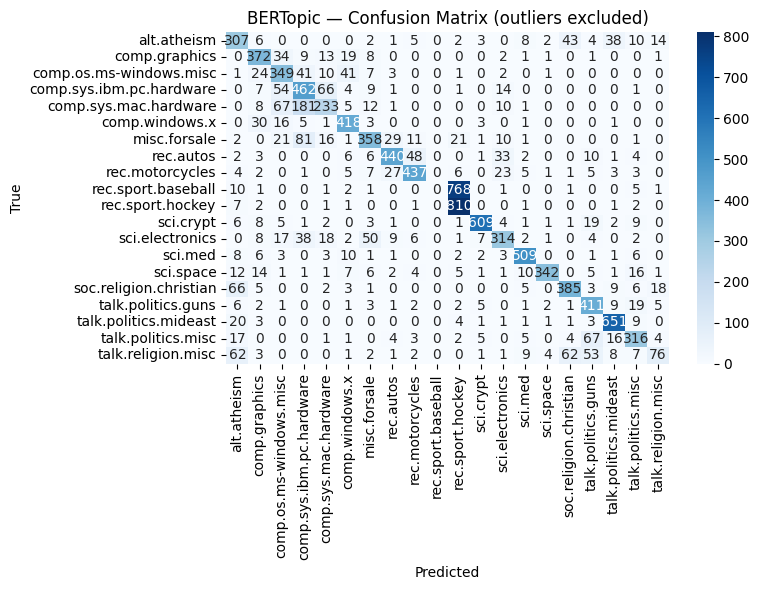

In [13]:
labels = sorted(df["label"].unique())

cm = confusion_matrix(df_eval["label"], df_eval["predicted_label"], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [14]:
print(classification_report(df_eval["label"], df_eval["predicted_label"], labels=labels))

                          precision    recall  f1-score   support

             alt.atheism       0.58      0.69      0.63       445
           comp.graphics       0.74      0.81      0.77       461
 comp.os.ms-windows.misc       0.61      0.73      0.67       480
comp.sys.ibm.pc.hardware       0.56      0.75      0.64       619
   comp.sys.mac.hardware       0.63      0.45      0.53       518
          comp.windows.x       0.79      0.87      0.83       478
            misc.forsale       0.75      0.65      0.69       553
               rec.autos       0.84      0.79      0.82       556
         rec.motorcycles       0.84      0.82      0.83       530
      rec.sport.baseball       0.00      0.00      0.00       791
        rec.sport.hockey       0.50      0.98      0.66       826
               sci.crypt       0.95      0.90      0.93       673
         sci.electronics       0.75      0.66      0.70       479
                 sci.med       0.90      0.92      0.91       556
         

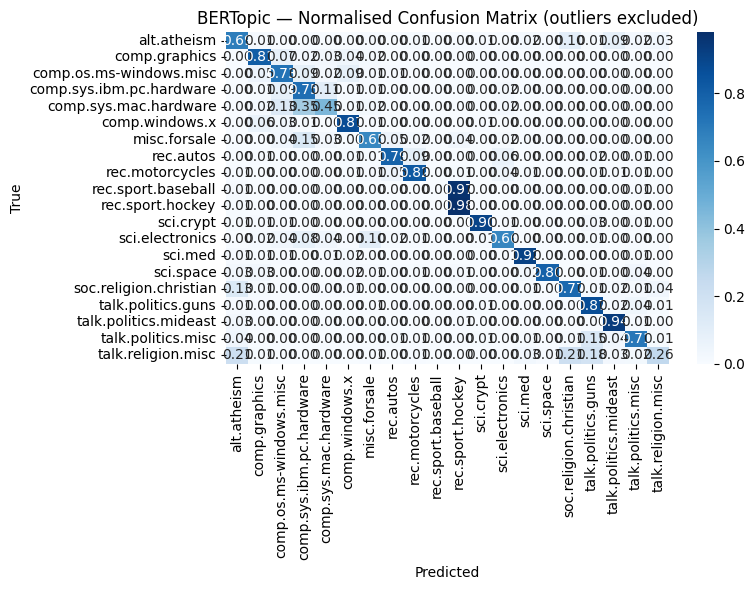

In [15]:
cm_norm = confusion_matrix(df_eval["label"], df_eval["predicted_label"],
                           labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [16]:
coverage = len(df_eval) / len(df)
outlier_breakdown = df[df["topic"] == -1]["label"].value_counts()

print(f"Coverage: {coverage:.1%}")
print("\nOutlier distribution by true label:")
print(outlier_breakdown)

Coverage: 65.7%

Outlier distribution by true label:
label
sci.space                   442
soc.religion.christian      418
comp.windows.x              413
comp.graphics               396
sci.electronics             388
comp.os.ms-windows.misc     379
talk.politics.guns          342
sci.med                     329
comp.sys.mac.hardware       319
rec.motorcycles             283
comp.sys.ibm.pc.hardware    281
rec.autos                   275
misc.forsale                256
alt.atheism                 251
talk.politics.misc          241
talk.religion.misc          235
sci.crypt                   200
talk.politics.mideast       141
rec.sport.baseball           22
rec.sport.hockey             17
Name: count, dtype: int64


In [17]:
# Total documents per true label
total_per_label = df["label"].value_counts()

# Percentage of each class that became an outlier
outlier_rate = (outlier_breakdown / total_per_label * 100).round(1)

print("Outlier rate by class:")
print(outlier_rate.sort_values(ascending=False))

Outlier rate by class:
label
sci.space                   50.7
comp.windows.x              46.4
comp.graphics               46.2
soc.religion.christian      45.4
sci.electronics             44.8
talk.religion.misc          44.6
comp.os.ms-windows.misc     44.1
talk.politics.guns          42.1
comp.sys.mac.hardware       38.1
sci.med                     37.2
alt.atheism                 36.1
talk.politics.misc          35.1
rec.motorcycles             34.8
rec.autos                   33.1
misc.forsale                31.6
comp.sys.ibm.pc.hardware    31.2
sci.crypt                   22.9
talk.politics.mideast       16.9
rec.sport.baseball           2.7
rec.sport.hockey             2.0
Name: count, dtype: float64


**Including outliers**

In [18]:
# Reassign outliers to their closest topic using embedding similarity
topics_updated = topic_model.reduce_outliers(documents=texts, topics=topics, strategy="embeddings")

remaining_outliers = sum(t == -1 for t in topics_updated)
print(f"Outliers before: {sum(t == -1 for t in topics)}")
print(f"Outliers after:  {remaining_outliers}")

Outliers before: 5628
Outliers after:  0


In [19]:
# Replace the topic column with the updated assignments
df["topic_updated"] = topics_updated
df["predicted_label_updated"] = df["topic_updated"].map(topic_to_label)

In [20]:
df

,text,label,topic,predicted_label,topic_updated,predicted_label_updated
0,\n\nI am sure some bashers of Pens fans are pr...,rec.sport.hockey,0,rec.sport.hockey,0,rec.sport.hockey
1,My brother is in the market for a high-perform...,comp.sys.ibm.pc.hardware,-1,NaN,67,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,talk.politics.mideast,-1,NaN,64,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,comp.sys.ibm.pc.hardware,2,comp.sys.ibm.pc.hardware,2,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,comp.sys.mac.hardware,65,comp.sys.ibm.pc.hardware,65,comp.sys.ibm.pc.hardware
...,...,...,...,...,...,...
16424,Hi to all.\n\nSince all of you could also be a...,misc.forsale,176,misc.forsale,176,misc.forsale
16425,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,sci.med,-1,NaN,31,sci.med
16426,I just installed a DX2-66 CPU in a clone mothe...,comp.sys.ibm.pc.hardware,86,comp.sys.ibm.pc.hardware,86,comp.sys.ibm.pc.hardware
16427,\nWouldn't this require a hyper-sphere. In 3-...,comp.graphics,18,comp.graphics,18,comp.graphics


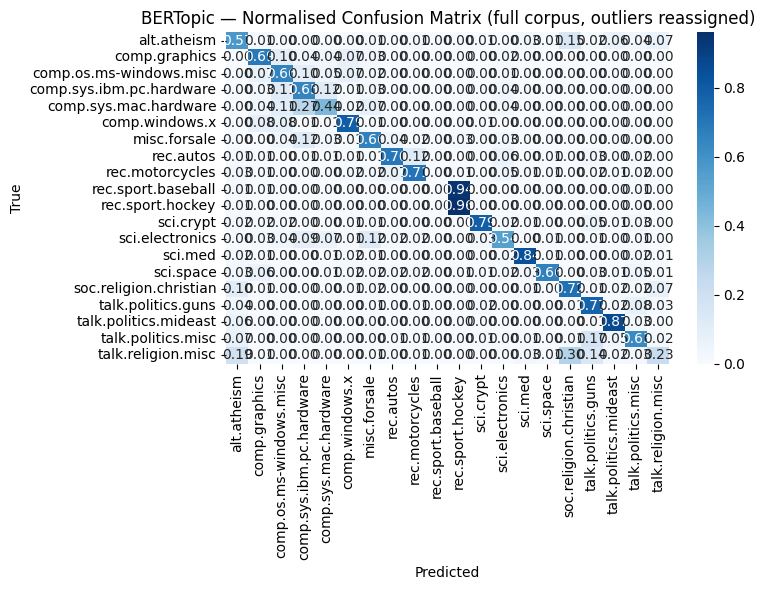

In [21]:
# Now evaluate on the entire corpus
cm_full = confusion_matrix(df["label"], df["predicted_label_updated"],
                           labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (full corpus, outliers reassigned)")
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(df["label"], df["predicted_label_updated"], labels=labels))

                          precision    recall  f1-score   support

             alt.atheism       0.46      0.57      0.51       696
           comp.graphics       0.63      0.69      0.66       857
 comp.os.ms-windows.misc       0.56      0.66      0.61       859
comp.sys.ibm.pc.hardware       0.52      0.65      0.58       900
   comp.sys.mac.hardware       0.54      0.44      0.48       837
          comp.windows.x       0.72      0.79      0.76       891
            misc.forsale       0.60      0.66      0.63       809
               rec.autos       0.80      0.70      0.74       831
         rec.motorcycles       0.76      0.71      0.74       813
      rec.sport.baseball       0.00      0.00      0.00       813
        rec.sport.hockey       0.50      0.96      0.66       843
               sci.crypt       0.88      0.79      0.83       873
         sci.electronics       0.64      0.54      0.58       867
                 sci.med       0.86      0.84      0.85       885
         

In [23]:
from sklearn.metrics import accuracy_score, f1_score

summary_df = pd.DataFrame({
    "Evaluated docs": [len(df_eval), len(df)],
    "Coverage": [f"{len(df_eval)/len(df):.1%}", "100%"],
    "Accuracy": [
        round(accuracy_score(df_eval["label"], df_eval["predicted_label"]), 3),
        round(accuracy_score(df["label"], df["predicted_label_updated"]), 3),
    ],
    "Macro F1": [
        round(f1_score(df_eval["label"], df_eval["predicted_label"], average="macro"), 3),
        round(f1_score(df["label"], df["predicted_label_updated"], average="macro"), 3),
    ],
}, index=["Outliers excluded", "Outliers reassigned"])

summary_df

,Evaluated docs,Coverage,Accuracy,Macro F1
Outliers excluded,10801,65.7%,0.722,0.702
Outliers reassigned,16429,100%,0.655,0.628


Clustering methods

In [24]:
file_path = "/content/corpus_20ng.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]

# Preview
df.head()

,text,split,label
0,\n\nI am sure some bashers of Pens fans are pr...,all,rec.sport.hockey
1,My brother is in the market for a high-perform...,all,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,all,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,all,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,all,comp.sys.mac.hardware


In [25]:
texts = df["text"].astype(str).tolist()

print(texts[:3])

["\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n", 'My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any other high-perf

In [26]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embeddings.shape)

Batches:   0%|          | 0/514 [00:00<?, ?it/s]

(16429, 384)


In [28]:
embeddings_norm = normalize(embeddings, norm="l2") #Normalization for similarity calculations

Labels to evaluate

In [29]:
true_labels = df["label"]

In [30]:
true_labels.unique()

array(['rec.sport.hockey', 'comp.sys.ibm.pc.hardware',
       'talk.politics.mideast', 'comp.sys.mac.hardware',
       'sci.electronics', 'talk.religion.misc', 'sci.med', 'sci.crypt',
       'rec.motorcycles', 'rec.autos', 'comp.windows.x', 'comp.graphics',
       'sci.space', 'talk.politics.guns', 'misc.forsale', 'alt.atheism',
       'rec.sport.baseball', 'talk.politics.misc',
       'comp.os.ms-windows.misc', 'soc.religion.christian'], dtype=object)

In [31]:
le = LabelEncoder()
true_labels_encoded = le.fit_transform(true_labels)

print(list(le.classes_))  #see label mapping

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


**KMeans**

In [32]:
k = 20

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings_norm)

print(kmeans_labels[:10])

[ 4  6 15 10  8  6 19  4  4  0]


In [33]:
ari = adjusted_rand_score(true_labels_encoded, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels_encoded, kmeans_labels)
sil = silhouette_score(embeddings_norm, kmeans_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Silhouette Score: {sil:.4f}")

ARI: 0.4018
NMI: 0.5711
Silhouette Score: 0.0323


**HDBScan**

In [35]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric='euclidean'
)

hdb_labels = hdb.fit_predict(embeddings_norm)

print(hdb_labels[:20])

[ 0  1  1  1 -1 -1 -1  0 -1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1]


In [36]:
noise_ratio = sum(hdb_labels == -1) / len(hdb_labels)
print(noise_ratio)

0.701686042972792


In [37]:
mask = hdb_labels != -1

filtered_labels = hdb_labels[mask]
filtered_true = true_labels_encoded[mask]
filtered_embeddings = embeddings_norm[mask]

print("Remaining points:", len(filtered_labels))

Remaining points: 4901


In [38]:
print("Unique labels:", np.unique(hdb_labels))
print("Noise points:", sum(hdb_labels == -1))
print("Num clusters:", len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0))

Unique labels: [-1  0  1]
Noise points: 11528
Num clusters: 2


In [39]:
ari_hdb = adjusted_rand_score(filtered_true, filtered_labels)
nmi_hdb = normalized_mutual_info_score(filtered_true, filtered_labels)

if len(set(filtered_labels)) > 1:
    sil_hdb = silhouette_score(filtered_embeddings, filtered_labels)
else:
    sil_hdb = -1

In [40]:
ari_hdb_full = adjusted_rand_score(true_labels_encoded, hdb_labels)
nmi_hdb_full = normalized_mutual_info_score(true_labels_encoded, hdb_labels)

print(f"HDBSCAN ARI (no noise): {ari_hdb:.4f}")
print(f"HDBSCAN ARI (full):     {ari_hdb_full:.4f}")
print(f"HDBSCAN NMI (no noise): {nmi_hdb:.4f}")
print(f"HDBSCAN NMI (full):     {nmi_hdb_full:.4f}")
print(f"HDBSCAN Silhouette:     {sil_hdb:.4f}")

HDBSCAN ARI (no noise): 0.0597
HDBSCAN ARI (full):     0.0169
HDBSCAN NMI (no noise): 0.2865
HDBSCAN NMI (full):     0.1210
HDBSCAN Silhouette:     0.0543


In [41]:
comparison = pd.DataFrame({
    'ARI': [ari, ari_hdb_full],
    'NMI': [nmi, nmi_hdb_full],
    'Silhouette': [sil, sil_hdb],
    'N_clusters': [
        k,
        len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0),
    ],
    'Coverage': [
        1.0,
        (hdb_labels != -1).mean(),
    ],
}, index=['KMeans', 'HDBSCAN']).round(3)

comparison

,ARI,NMI,Silhouette,N_clusters,Coverage
KMeans,0.402,0.571,0.032,20,1.000
HDBSCAN,0.017,0.121,0.054,2,0.298
